# Gold-Taxo Evaluation — Single Annotator
Évalue la qualité de la ressource sur le gold set (150 papiers) via l'export Label Studio.
- **Assignation taxonomique** : accuracy + macro-F1 (LLM vs gold humain)
- **Champs extraits** (lien, domaine, langue) : taux d'exactitude avec IC 95 %

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
)
import matplotlib.pyplot as plt

DATA = Path("../data")
LS_EXPORT = DATA / "evaluation" / "gold_taxo_export-2026-07-03-18-48-a94547a6.csv"
PARQUET = DATA / "corpus" / "single_task_benchmark_paper.parquet"
TAXONOMY = DATA / "taxonomy" / "manual_taxonomy_tree.json"


# Construit leaf → mother depuis le JSON de la taxonomie
# (évite le problème de Label Studio qui split les '/' dans les noms)
def _build_leaf_to_mother(
    node: dict, parent_label: str | None = None
) -> dict[str, str]:
    mapping: dict[str, str] = {}
    label = node["label"]
    children = [c for c in node.get("children", []) if isinstance(c, dict)]
    if parent_label is not None:  # on est sur un nœud non-racine
        if not children:  # feuille
            mapping[label] = parent_label
        else:  # nœud intermédiaire → récurse
            for child in children:
                mapping.update(_build_leaf_to_mother(child, label))
    else:  # racine → itère sur les mothers
        for child in node.get("children", []):
            mapping.update(_build_leaf_to_mother(child, child["label"]))
    return mapping


_taxo_json = json.loads(Path(TAXONOMY).read_text(encoding="utf-8"))
LEAF_TO_MOTHER: dict[str, str] = _build_leaf_to_mother(_taxo_json)

## 1. Chargement & parsing

In [2]:
def parse_task_leaf(val: str | float) -> str | None:
    if pd.isna(val):
        return None
    try:
        return json.loads(val)[0]["taxonomy"][0][-1]
    except (json.JSONDecodeError, KeyError, IndexError):
        return None


# Labels valides = feuilles de la taxonomie + "other"
VALID_LEAVES = set(LEAF_TO_MOTHER.keys()) | {"other"}

ann = pd.read_csv(LS_EXPORT)
ann["task_human"] = ann["task"].apply(parse_task_leaf)
# "other" se mappe à lui-même comme les leaf-mothers ; labels invalides → NaN
ann["mother_human"] = ann["task_human"].map(LEAF_TO_MOTHER).fillna(ann["task_human"])
ann.loc[~ann["task_human"].isin(VALID_LEAVES), "mother_human"] = None

ann_valid = ann[ann["skip"].isna()].copy()
print(
    f"Total : {len(ann)} | skipped : {ann['skip'].notna().sum()} | utilisables : {len(ann_valid)}"
)

invalid = ann_valid[
    ann_valid["task_human"].notna() & ~ann_valid["task_human"].isin(VALID_LEAVES)
]
if not invalid.empty:
    print(f"\nLabels invalides ({len(invalid)}) — à re-annoter dans Label Studio :")
    print(invalid[["bibkey", "task_human"]].to_string(index=False))

Total : 100 | skipped : 11 | utilisables : 89

Labels invalides (2) — à re-annoter dans Label Studio :
                                      bibkey       task_human
                        cheng-etal-2024-dont          Subject
preotiuc-pietro-devlin-marier-2019-analyzing Author Profiling


In [3]:
pq = pd.read_parquet(PARQUET, columns=["bibkey", "task", "mother_task"])
df = ann_valid.merge(pq, on="bibkey", suffixes=("_ann", "_llm"))
# task → task_llm, mother_task inchangé
print(f"Jointure : {len(df)} papiers")
df[["bibkey", "mother_human", "mother_task", "task_human", "task_llm"]].head()

Jointure : 89 papiers


,bibkey,mother_human,mother_task,task_human,task_llm
0,abercrombie-hovy-2016-putting,Non-literal,Non-literal,Figurative Language,Figurative Language
1,al-nabki-etal-2017-classifying,Topic / Subject,Topic / Subject,Generic Topic,Generic Topic
2,alavoine-etal-2024-sur,Machine-Generated Text,Machine-Generated Text,Machine-Generated Text,Machine-Generated Text
3,albanyan-etal-2023-finding,other,NLI,other,Pragmatic Inference
4,alharbi-hain-2016-opencourseware,Dialogue Act,Dialogue Act,Dialogue Act,Dialogue Act


## 2. Assignation taxonomique — LLM vs gold humain

In [4]:
taxo = df.dropna(subset=["task_human", "task_llm"])

y_true_leaf = taxo["task_human"]
y_pred_leaf = taxo["task_llm"]

# mother : exclut uniquement les 2 labels invalides (Subject, Author Profiling)
# "other" est conservé — il se self-mappe comme les leaf-mothers
taxo_m = taxo.dropna(subset=["mother_human", "mother_task"])
y_true_mother = taxo_m["mother_human"]
y_pred_mother = taxo_m["mother_task"]

rows = {}
for level, yt, yp in [
    ("Leaf", y_true_leaf, y_pred_leaf),
    ("Mother", y_true_mother, y_pred_mother),
]:
    rows[level] = {
        "n": len(yt),
        "accuracy": round(accuracy_score(yt, yp), 3),
        "macro-F1": round(f1_score(yt, yp, average="macro", zero_division=0), 3),
    }

pd.DataFrame(rows).T

,n,accuracy,macro-F1
Leaf,84.0,0.690,0.603
Mother,82.0,0.768,0.728


In [5]:
errors = taxo[y_true != y_pred][["bibkey", "task_human", "task_llm"]]
print(f"Erreurs : {len(errors)} / {len(taxo)}")
errors.rename(columns={"task_human": "gold", "task_llm": "llm"}).sort_values("gold")

NameError: name 'y_true' is not defined

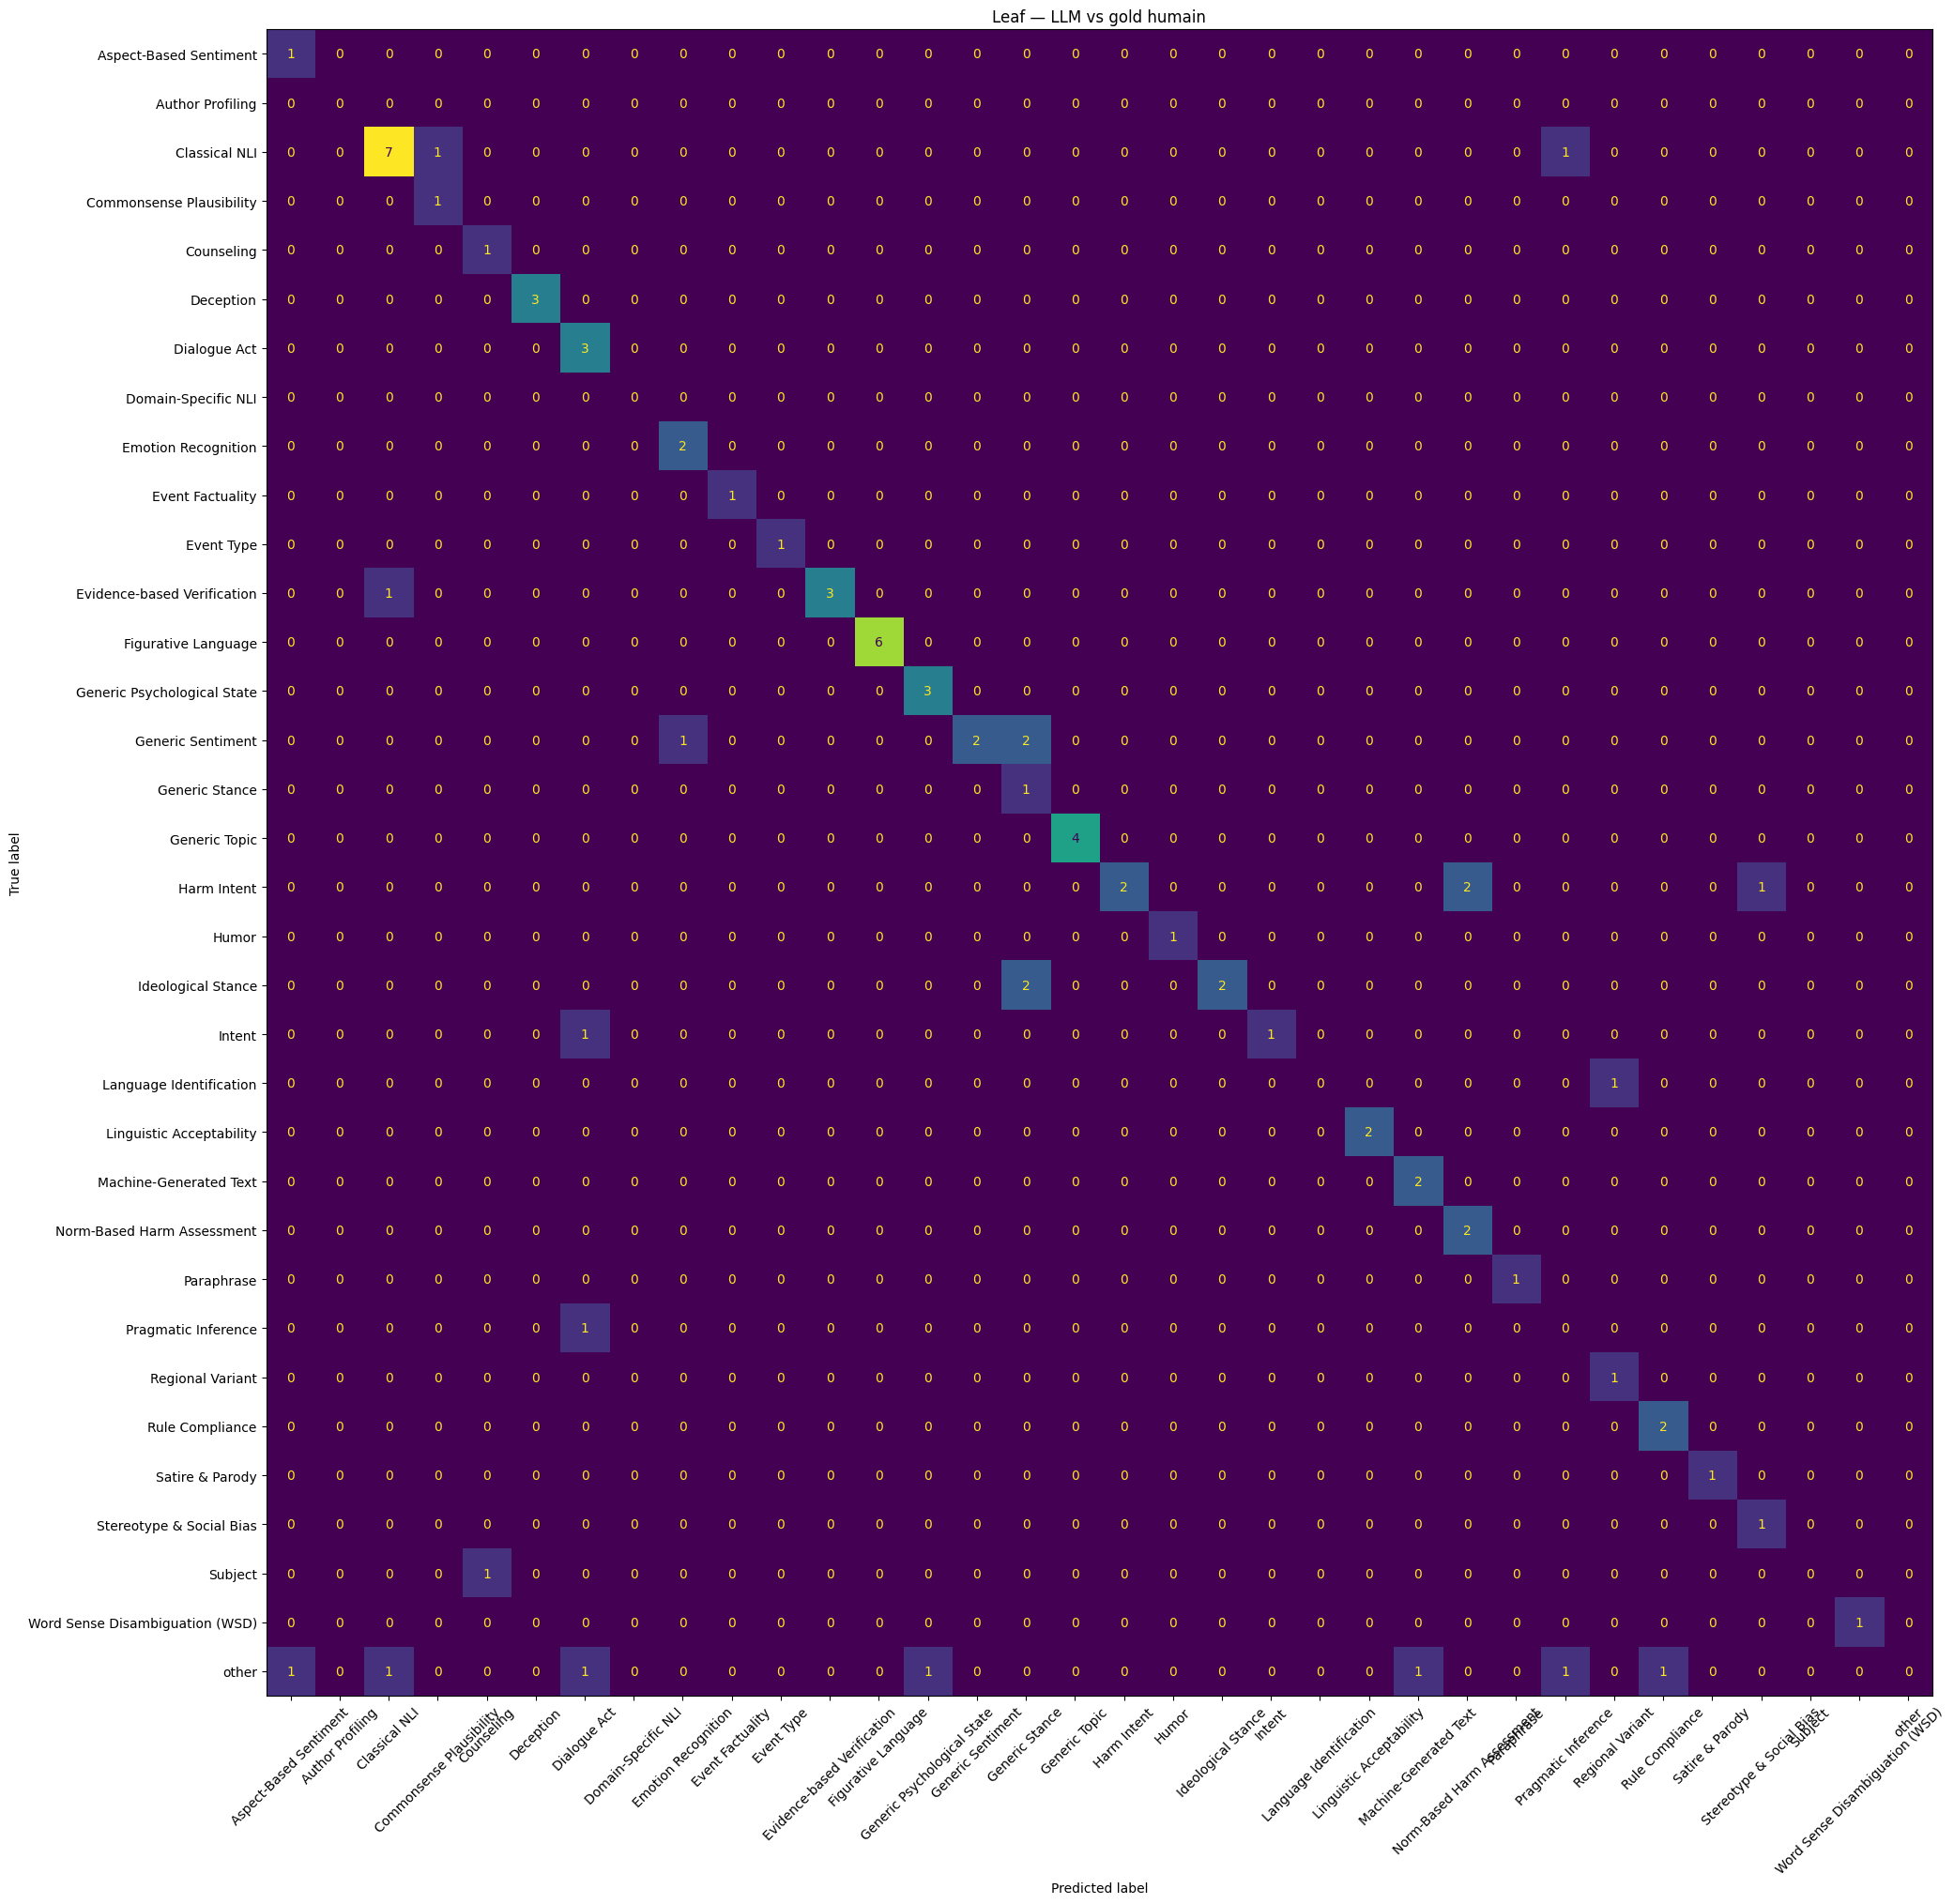

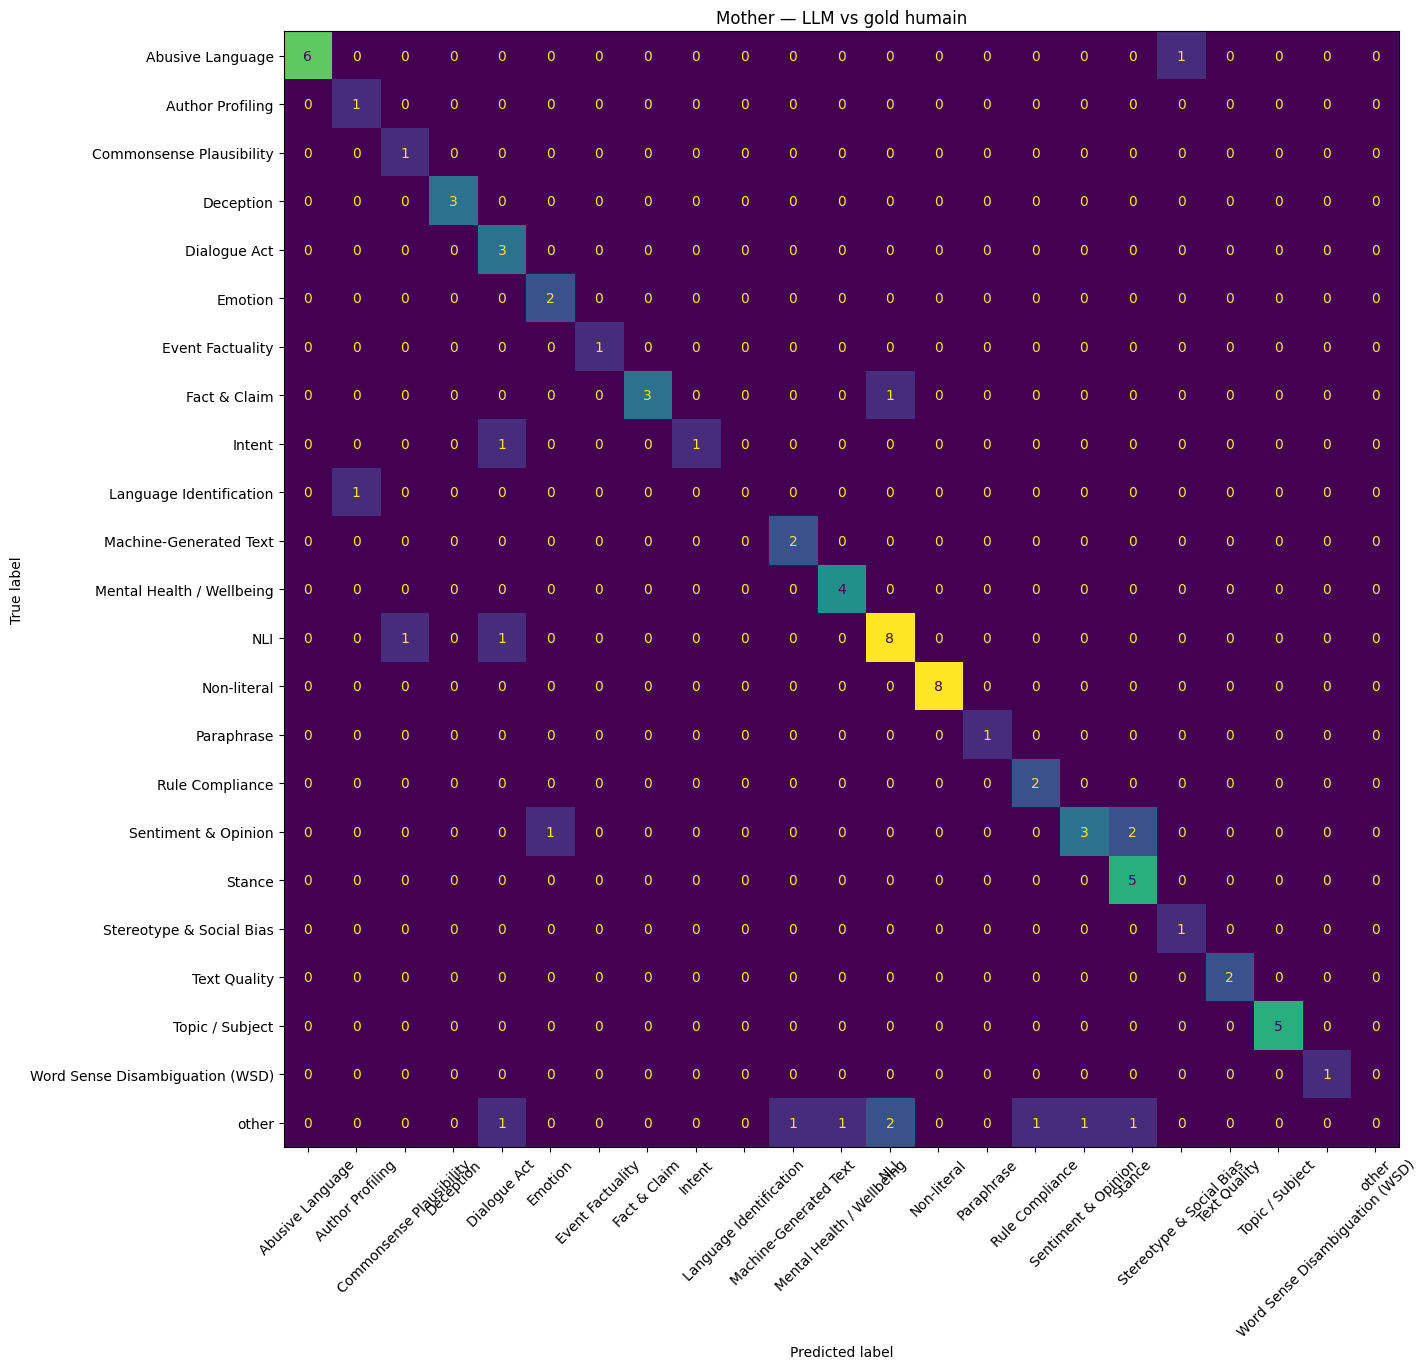

In [6]:
for title, yt, yp in [
    ("Leaf — LLM vs gold humain", y_true_leaf, y_pred_leaf),
    ("Mother — LLM vs gold humain", y_true_mother, y_pred_mother),
]:
    labels = sorted(yt.unique())
    cm = confusion_matrix(yt, yp, labels=labels)
    fig, ax = plt.subplots(
        figsize=(max(8, len(labels) * 0.7), max(6, len(labels) * 0.6))
    )
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 3. Champs extraits — exactitude avec IC 95 %

In [19]:
def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


def field_accuracy(series: pd.Series, correct_values: set) -> dict:
    valid = series.dropna()
    n = len(valid)
    k = valid.isin(correct_values).sum()
    lo, hi = wilson_ci(k, n)
    return {
        "n": n,
        "correct": int(k),
        "accuracy": round(k / n, 3) if n else 0,
        "ci_95_lo": round(lo, 3),
        "ci_95_hi": round(hi, 3),
    }


pd.DataFrame(
    {
        "Domaine": field_accuracy(ann_valid["domain_ok"], {"correct"}),
    }
).T

,n,correct,accuracy,ci_95_lo,ci_95_hi
Domaine,89.0,79.0,0.888,0.805,0.938


In [20]:
# Distribution lien dataset
link = ann_valid["link_status"].dropna()
counts = link.value_counts()
print("=== Lien dataset — distribution globale ===")
for status, n in counts.items():
    print(f"  {status:10s}: {n:3d}  ({n / len(link) * 100:.1f}%)")

# Métrique utile : parmi les papiers OÙ un lien a été trouvé (hors 'none'), combien sont valides ?
has_link = link[link != "none"]
n_has = len(has_link)
n_valid = (has_link == "valid").sum()
n_broken = (has_link == "broken").sum()
n_wrong = (has_link == "wrong").sum()
lo, hi = wilson_ci(n_valid, n_has)
print(f"\n=== Parmi les {n_has} papiers avec un lien ===")
print(
    f"  valid  : {n_valid:3d}  ({n_valid / n_has * 100:.1f}%)  IC95=({lo:.3f}, {hi:.3f})"
)
print(f"  broken : {n_broken:3d}  ({n_broken / n_has * 100:.1f}%)")
print(f"  wrong  : {n_wrong:3d}  ({n_wrong / n_has * 100:.1f}%)")
print(
    f"\n  Papiers sans lien ('none') : {counts.get('none', 0)} / {len(link)}  ({counts.get('none', 0) / len(link) * 100:.1f}%)"
)

=== Lien dataset — distribution globale ===
  valid     :  53  (59.6%)
  none      :  27  (30.3%)
  broken    :   7  (7.9%)
  wrong     :   2  (2.2%)

=== Parmi les 62 papiers avec un lien ===
  valid  :  53  (85.5%)  IC95=(0.747, 0.922)
  broken :   7  (11.3%)
  wrong  :   2  (3.2%)

  Papiers sans lien ('none') : 27 / 89  (30.3%)


In [21]:
# Langue : comparaison benchmark_languages (auto) vs language (gold humain)
# On compare après normalisation (strip, lower)
def lang_match(row) -> bool | None:
    auto = (
        str(row["benchmark_languages"]).strip().lower()
        if pd.notna(row["benchmark_languages"])
        else ""
    )
    human = str(row["language"]).strip().lower() if pd.notna(row["language"]) else ""
    if not auto and not human:
        return None
    # Label Studio exporte les choix multiples séparés par une virgule
    auto_set = set(x.strip() for x in auto.split(",") if x.strip())
    human_set = set(x.strip() for x in human.split(",") if x.strip())
    return auto_set == human_set


ann_valid = ann_valid.copy()
ann_valid["lang_match"] = ann_valid.apply(lang_match, axis=1)
lang_valid = ann_valid["lang_match"].dropna()
k_lang = lang_valid.sum()
n_lang = len(lang_valid)
lo, hi = wilson_ci(int(k_lang), n_lang)
print(
    f"Langue — n={n_lang}  correct={int(k_lang)}  accuracy={k_lang / n_lang:.3f}  IC95=({lo:.3f}, {hi:.3f})"
)

Langue — n=89  correct=0  accuracy=0.000  IC95=(0.000, 0.041)
